In [1]:
# Importamos las librerías básicas
import os
import mne
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, roc_auc_score, roc_curve, precision_score, auc 
from sklearn.preprocessing import StandardScaler

# from transformers import BertModel,BertConfig
from transformers import get_linear_schedule_with_warmup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(0)
device

c:\Users\THIN\OneDrive - Escuela Tecnologica Instituto Tecnico Central\Proyecto_cerebro\venv_cerebro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [2]:
def evaluar_modelo_clasificador(modelo, grid_params: dict, X: np.array, y: np.array, k: int, tipo_kfold="kfold" ):
    """
    Entrena un modelo con GridSearchCV y devuelve los resultados en DataFrame.
    tipo_kfold puede ser 'kfold' o 'stratified'.
    """
    if tipo_kfold == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=42)
    else:
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    grid = GridSearchCV(modelo, grid_params, cv=cv, scoring='accuracy', n_jobs=-1, verbose=2)
    grid.fit(X, y)

    return [{
        "Modelo": type(modelo).__name__,
        "KFold": tipo_kfold,
        "Mejor Puntaje": grid.best_score_,
        "Mejores Parámetros": grid.best_params_,
        "k": k
    }, grid]

In [5]:
df.isnull().sum()

Id_Patient            0
Hospital              0
Age                   1
Sex                   3
ROSC                304
OHCA                 41
Shockable Rhythm     32
TTM                  98
Outcome               0
CPC                   0
numeric_outcome       0
dtype: int64

In [ ]:
# X_eeg= torch.stack(data, dim=0)
X_eeg=torch.cat(data,dim=0)
X_eeg=X_eeg.reshape(len(demograp_data),X_eeg.shape[0]//len(demograp_data),19,wind_size)
# Y_eeg= torch.tensor(np.array(demograp_data["numeric_outcome"],dtype=float)).long()
Y_eeg= torch.tensor(np.array(demograp_data["CPC"],dtype=float)).long()

X_train, X_test, y_train, y_test= train_test_split(X_eeg, Y_eeg, test_size=0.2, random_state=0, stratify=Y_eeg)

n_splits=10
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)


# Elegimos el optimizador
num_classes=len(Y_eeg.unique())
X_eeg.shape

In [138]:
pd.Series(Y_eeg.tolist()).value_counts(normalize=True)

0    0.6
1    0.4
Name: proportion, dtype: float64

# LSTM

In [15]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, num_classes, dropout_layer:float=0.1, conv_2d_layer:int=32, linear_layer_classifier: int= 64, 
                 cnn_out=32, lstm_hidden=128, lstm_layers=2):
        super().__init__()

        # --- CNN para procesar espacialmente los 19x512 ---
        self.cnn = nn.Sequential(
            nn.Conv2d(1, conv_2d_layer, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(conv_2d_layer),
            nn.ReLU(),
            nn.Conv2d(conv_2d_layer, cnn_out, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(cnn_out),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))   # Reduce (19,512) -> (1,1)
        )

        # --- LSTM para procesar la secuencia temporal ---
        self.lstm = nn.LSTM(
            input_size=cnn_out,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.1,
            bidirectional=False,
        )

        # --- Clasificador final ---
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, linear_layer_classifier),
            nn.ReLU(),
            nn.Dropout(dropout_layer),
            nn.Linear(linear_layer_classifier, num_classes)
        )

    def forward(self, x):
        """
        x: tensor de forma [Batch, T: patches, Channels, Frequency]
        """
        B, T, C, F = x.shape
        cnn_features = []

        # Paso 1: procesar cada instante temporal con la CNN
        for t in range(T):
            # x[:, t]: [B, C, F]
            xt = x[:, t].unsqueeze(1)  # -> [B, 1, C, F]
            feat_t = self.cnn(xt)      # -> [B, cnn_out, 1, 1]
            # print(feat_t.view(B, -1).shape)
            feat_t = feat_t.view(B, -1)  # -> [B, cnn_out]
            cnn_features.append(feat_t)

        # Paso 2: reconstruir la secuencia temporal
        seq = torch.stack(cnn_features, dim=1)  # [B, T, cnn_out]

        # Paso 3: procesar con LSTM
        lstm_out, (h, c) = self.lstm(seq)       # [B, T, lstm_hidden]

        # Paso 4: usar la última salida de la secuencia
        last_output = lstm_out[:, -1, :]        # [B, lstm_hidden]

        # Paso 5: clasificar
        out = self.classifier(last_output)
        return out

In [ ]:
model_LSTM=CNN_LSTM_Model(num_classes=num_classes, cnn_out=32, lstm_hidden=32, lstm_layers=2).to(device)
batch_size=32
accuracy_test=0
epochs=250
# Entrenamiento por mini-lotes
for fold, (train_idx, test_idx) in enumerate(cv.split(X_train.cpu(), y_train.cpu())):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model_LSTM.parameters(), lr=2e-4)
    total_steps = len(train_idx) * 8  # epochs later, adjust EPOCHS accordingly
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=25, num_training_steps=max(1, total_steps))
    Acc_scores = []
    Loss_score=[]
    for epoch in range(epochs):
        model_LSTM.train()
        model_LSTM.to(device)
        idx = train_idx[torch.randperm(len(train_idx))]
        for i in range(0, len(idx), batch_size):
            batch_idx = idx[i:i + batch_size]

            X_batch = X_eeg[batch_idx].float().to(device)
            y_batch = Y_eeg[batch_idx].float().to(device)

            optimizer.zero_grad()
            outputs = model_LSTM(X_batch)
            loss = criterion(outputs, y_batch.long())
            loss.backward()
            optimizer.step()
            scheduler.step()
        
        if epoch % int(epochs/100) == 0:
            with torch.no_grad():
                model_LSTM.eval()
                Loss_score.append(loss.item())
                pred = torch.argmax(model_LSTM(X_train[train_idx].float().to(device)), dim=1)
                acc_train = (pred == y_train[train_idx].float().to(device)).float().mean().item()
                Acc_scores.append(acc_train)

        if epoch % (epochs/10)== 0:
                print(f"[Fold {fold+1}] Época {epoch}: pérdida={loss.item():.4f}, acc_train={acc_train:.3f}")
            
    

    model_LSTM.eval()
    with torch.no_grad():
        logits = model_LSTM(X_train[test_idx].float().to(device))
        preds = torch.argmax(torch.softmax(logits.float().to(device), dim=1), dim=1)
        acc = (preds == y_train[test_idx].to(device)).float().mean().item()
        accuracy_test+=acc
        print(f"[Fold {fold+1}] Precisión validación: {acc:.3f}")


print("Average kfold accuracy: ", accuracy_test/n_splits)


[Fold 1] Época 0: pérdida=0.6868, acc_train=0.580
[Fold 1] Época 25: pérdida=0.6165, acc_train=0.656
[Fold 1] Época 50: pérdida=0.5732, acc_train=0.699


In [ ]:
model_LSTM.eval()
with torch.no_grad():
    logits = model_LSTM(X_test.float().to(device))
    y_pred = torch.argmax(torch.softmax(logits, dim=1), dim=1)
    y_score=torch.softmax(logits, dim=1).cpu()
    acc = (y_pred == y_test.to(device)).float().mean().item()
    y_pred=y_pred.cpu()

    plt.plot(sorted(Acc_scores))
    plt.title("Accuraccy performance")
    plt.xlabel("epochs")
    plt.ylabel("Accuracy")
    plt.show()
    plt.plot(sorted(Loss_score, reverse=True))
    plt.title("Loss performance")
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.show()
model_name="LSTM model"
m_conf=confusion_matrix(y_test, y_pred)
S_labels=["Poor", "Good"]
sns.heatmap(m_conf, annot=True, fmt="d", xticklabels=S_labels, yticklabels=S_labels)
plt.title(f"{model_name}, accuracy_training= {round((accuracy_test/n_splits),2)}")



accuracy=accuracy_score(y_test,y_pred)
print("Exactitud: ",accuracy)
recall=recall_score(y_test,y_pred,average="weighted",)
print("Exhaustividad: ", recall)
precision=precision_score(y_test,y_pred,average="weighted")
print("Precisión", precision)
f1=f1_score(y_test,y_pred,average="weighted")
print("f1_score", f1)

# Si el modelo es de dos clases
if num_classes==2:
    fpr, tpr, thresholds = roc_curve(y_test, y_score=y_score[:,1])
    roc_auc = auc(fpr, tpr)

    # 6. Graficar la curva ROC
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
    plt.xlabel('Tasa de falsos positivos (FPR)')
    plt.ylabel('Tasa de verdaderos positivos (TPR)')
    plt.title('Curva ROC - Clasificación binaria')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# BERT

In [110]:
# Cell 9: model
class EEGBertClassifier(nn.Module):
    def __init__(self, n_channels, patch_size, n_tokens, bert_hidden=128, bert_layers=4, nhead=8, num_classes=2, dropout=0.1):
        super().__init__()
        self.n_channels = n_channels
        self.patch_size = patch_size
        self.n_tokens = n_tokens

        # project patch (ch, patch_size) -> embedding vector of size bert_hidden
        self.patch_proj = nn.Sequential(
            nn.Conv1d(in_channels=n_channels, out_channels=bert_hidden, kernel_size=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LayerNorm(bert_hidden)
        )

        config = BertConfig(
            vocab_size=30522,
            hidden_size=bert_hidden,
            num_hidden_layers=bert_layers,
            num_attention_heads=nhead,
            intermediate_size=bert_hidden * 4,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            hidden_act="gelu",
            max_position_embeddings=n_tokens
        )
        self.bert = BertModel(config)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(bert_hidden, num_classes)
        )

    def forward(self, x):
        B, T, C, P = x.shape
        x_resh = x.view(B * T, C, P)
        emb = self.patch_proj(x_resh)  # (B*T, bert_hidden)
        emb = emb.view(B, T, -1)       # (B, T, bert_hidden)
        attention_mask = torch.ones((B, T), dtype=torch.long, device=emb.device)
        outputs = self.bert(inputs_embeds=emb, attention_mask=attention_mask)
        try:
            pooled = outputs.pooler_output
            if pooled is None:
                pooled = outputs.last_hidden_state.mean(dim=1)
        except:
            pooled = outputs.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled)
        return logits

In [ ]:
model_BERT=EEGBertClassifier(n_channels=19, patch_size=wind_size, n_tokens=1024, num_classes=num_classes).to(device)
batch_size=64
accuracy_test=0
epochs=250
# Entrenamiento por mini-lotes
for fold, (train_idx, test_idx) in enumerate(cv.split(X_train.cpu(), y_train.cpu())):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model_BERT.parameters(), lr=2e-4)
    total_steps = len(train_idx) * 8  # epochs later, adjust EPOCHS accordingly
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=25, num_training_steps=max(1, total_steps))
    Acc_scores = []
    Loss_score=[]
    for epoch in range(epochs):
        model_BERT.train()
        model_BERT.to(device)
        idx = train_idx[torch.randperm(len(train_idx))]
        for i in range(0, len(idx), batch_size):
            batch_idx = idx[i:i + batch_size]

            X_batch = X_eeg[batch_idx].float().to(device)
            y_batch = Y_eeg[batch_idx].float().to(device)

            optimizer.zero_grad()
            outputs = model_BERT(X_batch)
            loss = criterion(outputs, y_batch.squeeze().long())
            loss.backward()
            optimizer.step()
            scheduler.step()
        
        if epoch % int(epochs/100) == 0:
            with torch.no_grad():
                model_BERT.eval()
                Loss_score.append(loss.item())
                pred = torch.argmax(model_BERT(X_train[train_idx].float().to(device)), dim=1)
                acc_train = (pred == y_train[train_idx].float().to(device)).float().mean().item()
                Acc_scores.append(acc_train)

        if epoch % (epochs/10)== 0:
                print(f"[Fold {fold+1}] Época {epoch}: pérdida={loss.item():.4f}, acc_train={acc_train:.3f}")
            
    

    model_BERT.eval()
    with torch.no_grad():
        logits = model_BERT(X_train[test_idx].float().to(device))
        preds = torch.argmax(torch.softmax(logits.float().to(device), dim=1), dim=1)
        acc = (preds == y_train[test_idx].to(device)).float().mean().item()
        accuracy_test+=acc
        print(f"[Fold {fold+1}] Precisión validación: {acc:.3f}")


print("Average kfold accuracy: ", accuracy_test/n_splits)


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


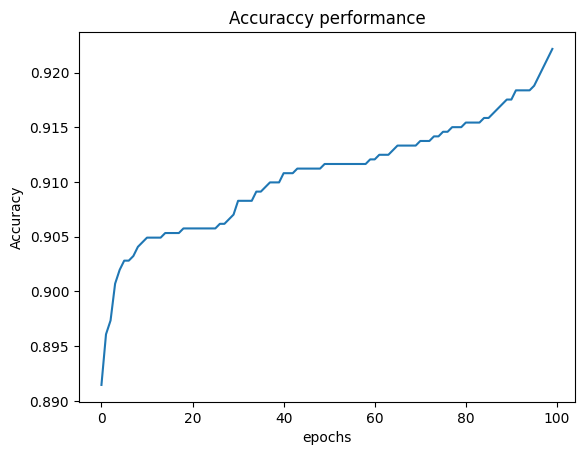

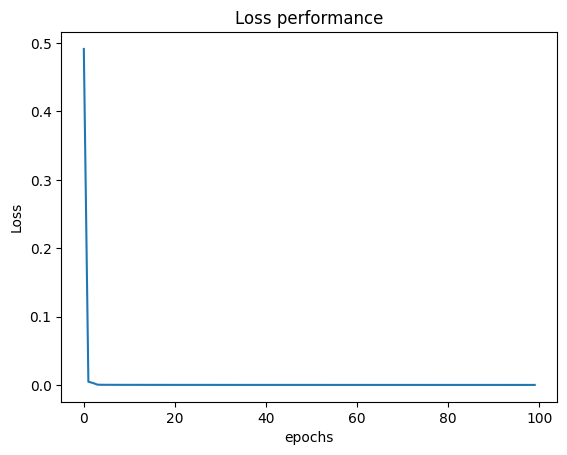

Exactitud:  0.8988642509464575
Exhaustividad:  0.8988642509464575
Precisión 0.898718133308842
f1_score 0.8984149978510214


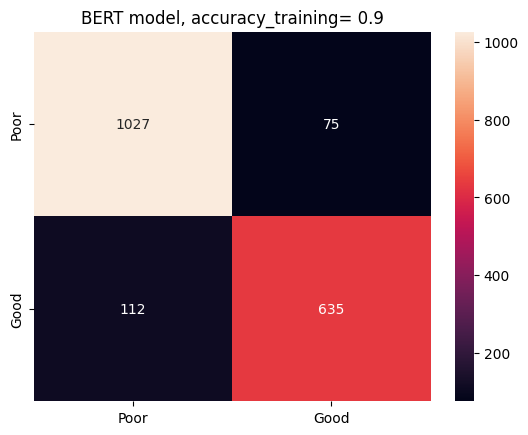

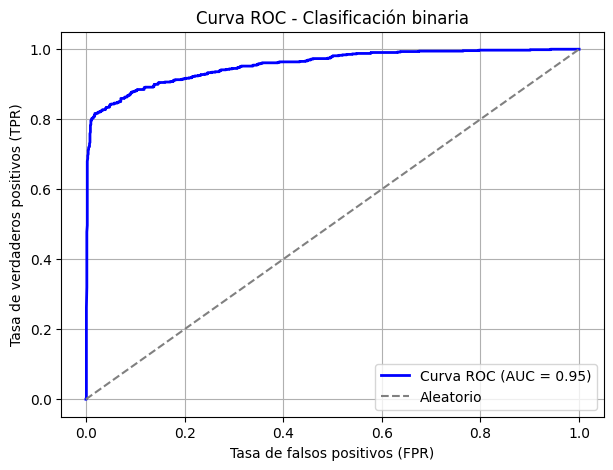

In [64]:
model_BERT.eval()
with torch.no_grad():
    logits = model_BERT(X_test.float().to(device))
    y_pred = torch.argmax(torch.softmax(logits, dim=1), dim=1)
    y_score=torch.softmax(logits, dim=1).cpu()
    acc = (y_pred == y_test.to(device)).float().mean().item()
    y_pred=y_pred.cpu()

    plt.plot(sorted(Acc_scores))
    plt.title("Accuraccy performance")
    plt.xlabel("epochs")
    plt.ylabel("Accuracy")
    plt.show()
    plt.plot(sorted(Loss_score, reverse=True))
    plt.title("Loss performance")
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.show()
model_name="BERT model"
m_conf=confusion_matrix(y_test, y_pred)
S_labels=["Poor", "Good"]
sns.heatmap(m_conf, annot=True, fmt="d", xticklabels=S_labels, yticklabels=S_labels)
plt.title(f"{model_name}, accuracy_training= {round((accuracy_test/n_splits),2)}")



accuracy=accuracy_score(y_test,y_pred)
print("Exactitud: ",accuracy)
recall=recall_score(y_test,y_pred,average="weighted",)
print("Exhaustividad: ", recall)
precision=precision_score(y_test,y_pred,average="weighted")
print("Precisión", precision)
f1=f1_score(y_test,y_pred,average="weighted")
print("f1_score", f1)

# Si el modelo es de dos clases
if num_classes==2:
    fpr, tpr, thresholds = roc_curve(y_test, y_score=y_score[:,1])
    roc_auc = auc(fpr, tpr)

    # 6. Graficar la curva ROC
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
    plt.xlabel('Tasa de falsos positivos (FPR)')
    plt.ylabel('Tasa de verdaderos positivos (TPR)')
    plt.title('Curva ROC - Clasificación binaria')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()